In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

Load the Dataset

In [32]:
from datetime import datetime
import pandas as pd

def parse_date(date):
    try:
        return datetime.strptime(date, "%d-%b-%y")
    except ValueError:
        return datetime.strptime(date, "%b %d, %Y")

df = pd.read_csv("../data/raw/BrentOilPrices.csv")

df["Date"] = df["Date"].apply(parse_date)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB


Inspect the Dataset

In [33]:
df.shape

(9011, 2)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB


In [35]:
df.describe()

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958720,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


In [36]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

Convert Date

In [37]:
df = df.sort_values("Date")
df.reset_index(drop=True, inplace=True)

df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [38]:
from datetime import datetime

for i, date in enumerate(df["Date"]):
    try:
        datetime.strptime(date, "%d-%b-%y")
    except Exception as e:
        print(f"Row {i}: {date}")
        print(e)
        break

Row 0: 1987-05-20 00:00:00
strptime() argument 1 must be str, not Timestamp


In [28]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%b-%y"
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB


In [29]:
df = df.sort_values("Date")
df.reset_index(drop=True, inplace=True)

Display Dataset

In [30]:
df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [14]:
df.tail()

,Date,Price
9006,2022-11-08,96.85
9007,2022-11-09,93.05
9008,2022-11-10,94.25
9009,2022-11-11,96.37
9010,2022-11-14,93.59


Plot Brent Oil Prices

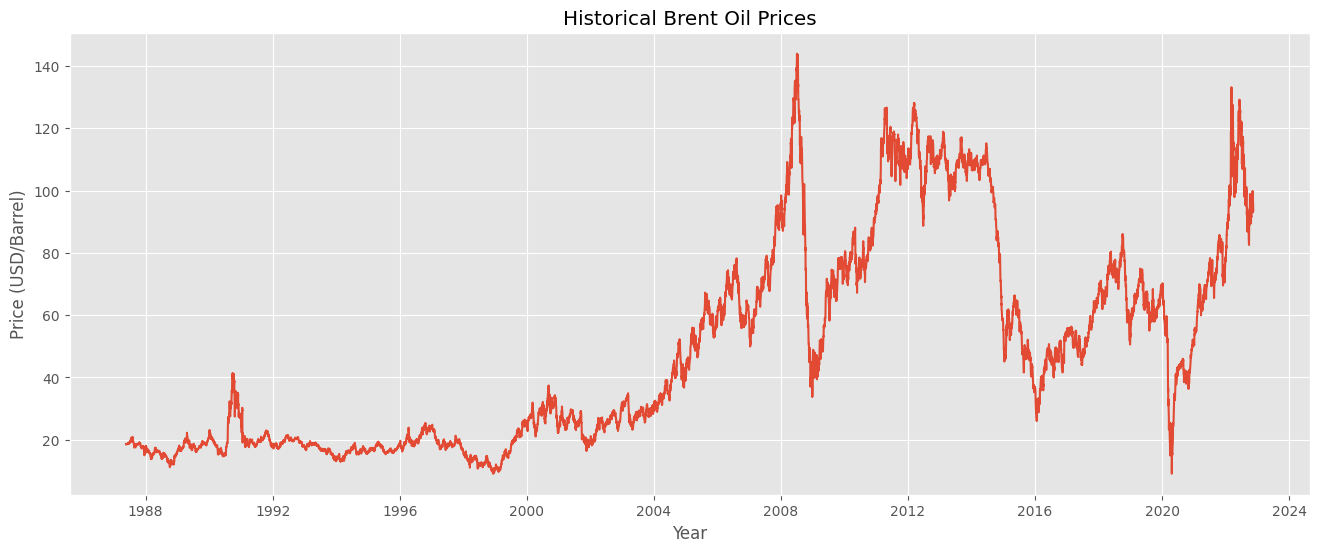

In [40]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["Price"])

plt.title("Historical Brent Oil Prices")

plt.xlabel("Year")

plt.ylabel("Price (USD/Barrel)")

plt.show()

Initial Observations
Historical Brent Oil Price Analysis

The historical Brent crude oil price series spans from May 1987 to September 2022, comprising 9,011 daily observations. The visualization reveals substantial variability in oil prices over the study period, reflecting the influence of geopolitical, economic, and market-related events.

Several important patterns can be observed:

The oil price remained relatively stable between 1987 and the early 2000s, fluctuating mostly between USD 15 and USD 30 per barrel.
Beginning around 2003, Brent oil prices entered a prolonged upward trend, reaching a historical peak of approximately USD 145 per barrel in 2008, largely associated with increased global demand before the global financial crisis.
Following the 2008 peak, prices experienced a sharp decline during the Global Financial Crisis, demonstrating a significant structural change in the series.
Following the 2008 peak, prices experienced a sharp decline during the Global Financial Crisis, demonstrating a significant structural change in the series.
Between 2011 and 2014, prices remained consistently high, generally above USD 100 per barrel, before declining sharply during the 2014–2016 oil market downturn.
A dramatic price collapse occurred in 2020 during the COVID-19 pandemic, representing one of the most significant shocks in the dataset.
From 2021 onward, prices recovered rapidly due to increased demand and geopolitical tensions, including the Russia–Ukraine conflict.

Overall, the series exhibits:

Long-term trends
Sharp structural breaks
Periods of high volatility
Non-constant mean and variance over time

These characteristics indicate that Brent oil prices are non-stationary and support the use of Bayesian Change Point Analysis to identify structural changes associated with major geopolitical and economic events

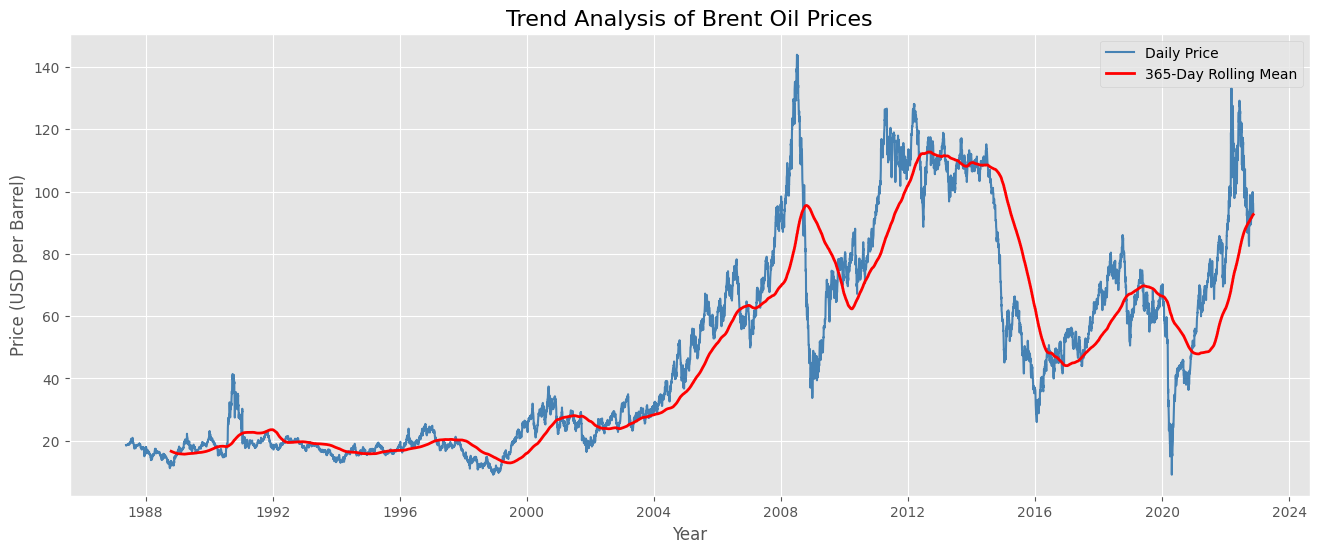

In [41]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["Price"], label="Daily Price", color="steelblue")

rolling_mean = df["Price"].rolling(window=365).mean()

plt.plot(
    df["Date"],
    rolling_mean,
    color="red",
    linewidth=2,
    label="365-Day Rolling Mean"
)

plt.title("Trend Analysis of Brent Oil Prices", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Price (USD per Barrel)")

plt.legend()

plt.grid(True)

plt.show()

In [42]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Price"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] < 0.05:
    print("\n→ Series is STATIONARY (reject H0)")
else:
    print("\n→ Series is NON-STATIONARY (fail to reject H0)")

ADF Statistic: -1.993856011392466
p-value: 0.2892735048934034
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669

→ Series is NON-STATIONARY (fail to reject H0)


In [43]:
import numpy as np

df["log_price"] = np.log(df["Price"])
df["log_return"] = df["log_price"].diff()

df[["Date", "Price", "log_price", "log_return"]].head()

,Date,Price,log_price,log_return
0,1987-05-20,18.63,2.924773,NaN
1,1987-05-21,18.45,2.915064,-0.009709
2,1987-05-22,18.55,2.920470,0.005405
3,1987-05-25,18.60,2.923162,0.002692
4,1987-05-26,18.63,2.924773,0.001612


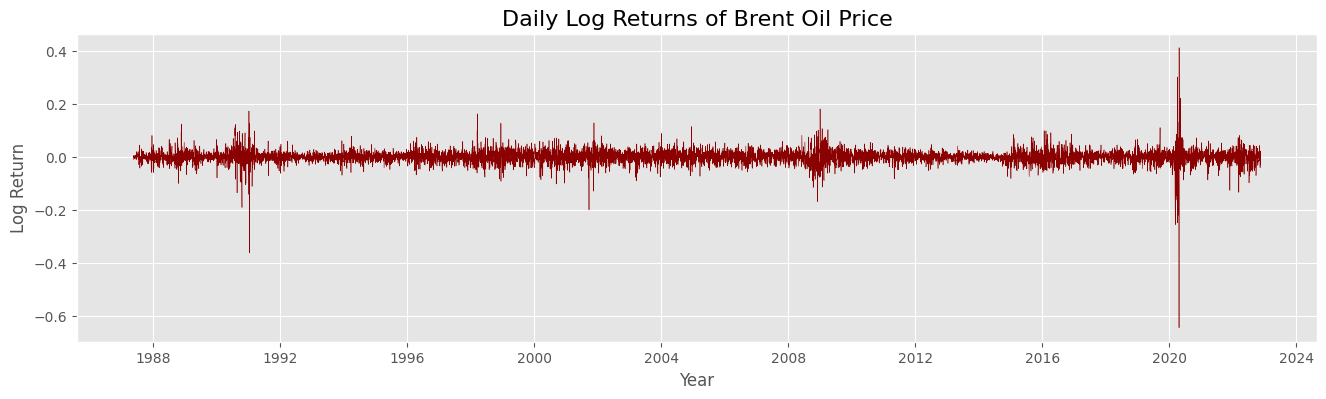

In [44]:
plt.figure(figsize=(16,4))
plt.plot(df["Date"], df["log_return"], color="darkred", linewidth=0.4)
plt.title("Daily Log Returns of Brent Oil Price", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

In [45]:
result_returns = adfuller(df["log_return"].dropna())

print("ADF Statistic:", result_returns[0])
print("p-value:", result_returns[1])
print("Critical Values:")
for key, value in result_returns[4].items():
    print(f"   {key}: {value:.4f}")

if result_returns[1] < 0.05:
    print("\n→ Log returns are STATIONARY (reject H0)")
else:
    print("\n→ Log returns are NON-STATIONARY")

ADF Statistic: -16.427113494485837
p-value: 2.4985801611432117e-29
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669

→ Log returns are STATIONARY (reject H0)


In [46]:
# Check for the extreme outlier
extreme = df[df["log_return"].abs() > 0.3]
print(extreme[["Date", "Price", "log_return"]])

           Date  Price  log_return
936  1991-01-17  21.10   -0.361214
8348 2020-04-02  20.24    0.301613
8359 2020-04-21   9.12   -0.643699
8360 2020-04-22  13.77    0.412023


load events and overlay on the price chart

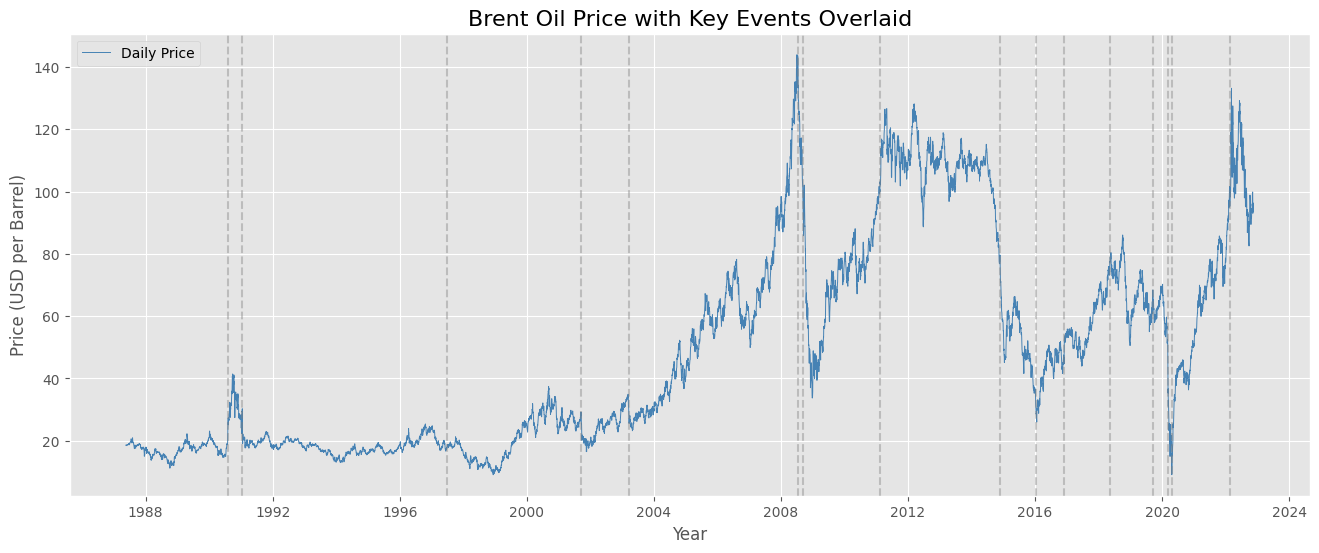

In [50]:
events = events = pd.read_csv("../data/external/key_events.csv", parse_dates=["start_date"])

plt.figure(figsize=(16,6))
plt.plot(df["Date"], df["Price"], color="steelblue", linewidth=0.7, label="Daily Price")

for _, row in events.iterrows():
    plt.axvline(row["start_date"], color="grey", linestyle="--", alpha=0.4)

plt.title("Brent Oil Price with Key Events Overlaid", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Price (USD per Barrel)")
plt.legend()
plt.grid(True)
plt.show()